In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
dataset_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Dataset\MT_dataset_with_all_structs.csv"
dataset_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\DL_NTCP_Multitox\datasets\MT_dataset\stratified_sampling_test_542.csv"
df = pd.read_csv(dataset_dir, sep=';')

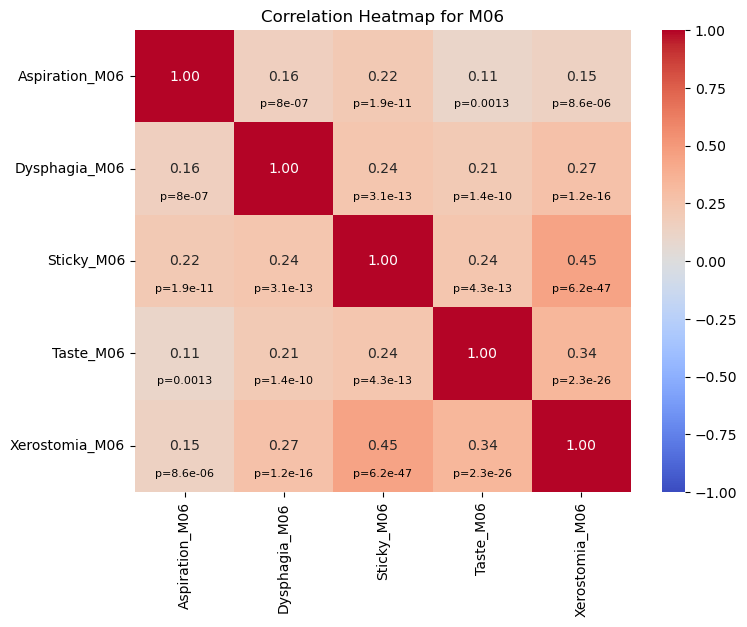

In [ ]:


from scipy.stats import pearsonr

toxicities = ["Aspiration", "Dysphagia", "Sticky", "Taste", "Xerostomia"]

timepoints = ["W04", "W05", "W06", "W07", "W12", "M06", "M12"]

timepoints = ["M06"]

for timepoint in timepoints:
    # Filter columns for the current timepoint
    cols = [toxicity + "_" + timepoint for toxicity in toxicities if toxicity + "_" + timepoint in df.columns]
    filtered_df = df[cols].replace(-1, np.nan).dropna()
    if cols:
        # Compute the correlation matrix and p-values
        corr_matrix = filtered_df.corr()
        p_values = filtered_df.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(len(corr_matrix))

        # Plot the heatmap with correlations
        plt.figure(figsize=(8, 6))
        plt.title(f"Correlation Heatmap for {timepoint}")
        sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

        # Overlay p-values as significance markers
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix)):
                if i != j:
                    plt.text(j + 0.5, i + 0.8, f"p={p_values.iloc[i, j]:.2g}",
                        ha='center', va='center', color='black', fontsize=8)

        plt.show()

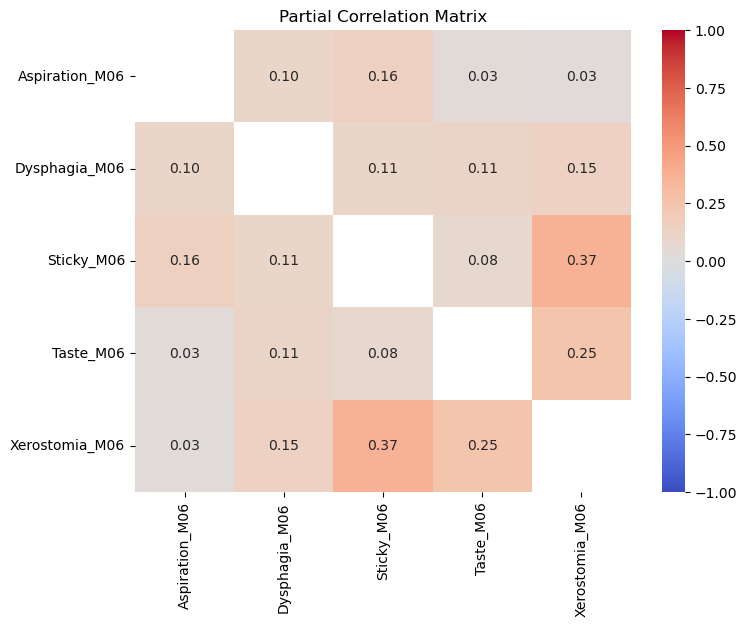

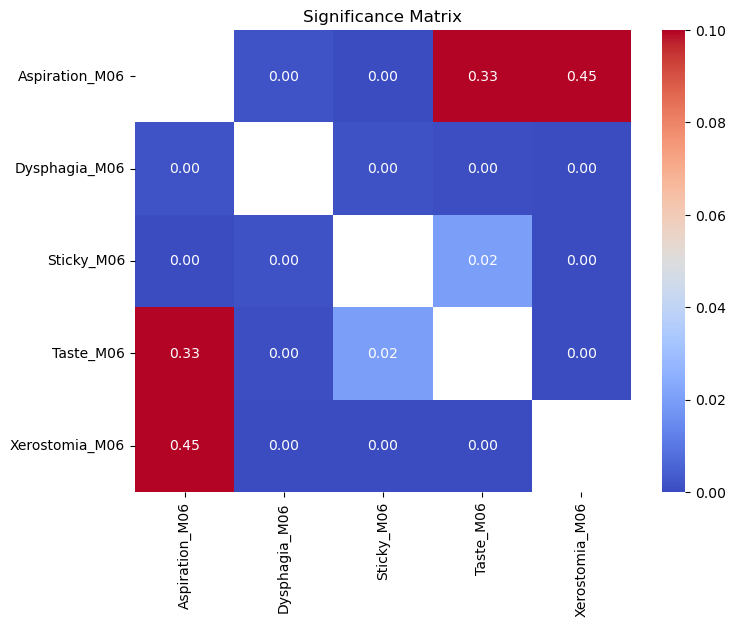

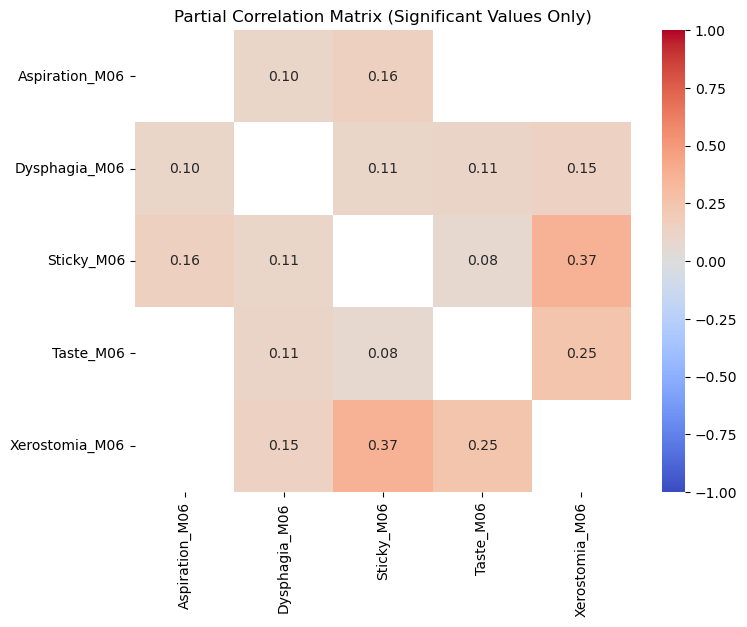

In [21]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
from pingouin import partial_corr
import matplotlib.pyplot as plt


predictions = filtered_df.copy()
toxicity_columns = predictions.columns.tolist()


# Calculate the partial correlations between toxicity predictions
partial_correlation_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)
significance_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)

for col1 in toxicity_columns:
    for col2 in toxicity_columns:
        if col1 == col2:
            partial_correlation_matrix.loc[col1, col2] = np.nan  # Self-correlation is 1
            significance_matrix.loc[col1, col2] = np.nan  # No significance for self-correlation
        else:
            # Calculate partial correlation controlling for all other variables
            control_vars = [col for col in toxicity_columns if col not in [col1, col2]]
            result = partial_corr(data=predictions, x=col1, y=col2, covar=control_vars, method='spearman') # , alternative='greater')
            partial_correlation_matrix.loc[col1, col2] = result['r'].values[0]
            significance_matrix.loc[col1, col2] = result['p-val'].values[0]

# Convert to numeric for better readability
partial_correlation_matrix = partial_correlation_matrix.astype(float)
significance_matrix = significance_matrix.astype(float)

# Plot the partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(partial_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Partial Correlation Matrix')
plt.show()

# plot the significance matrix
plt.figure(figsize=(8, 6))
sns.heatmap(significance_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmax=0.1)
plt.title('Significance Matrix')
plt.show()

# Mask non-significant values
mask = significance_matrix > 0.05  # Mask values with p-value > 0.05

# Apply the mask to the partial correlation matrix
masked_partial_corr = partial_correlation_matrix.copy()
masked_partial_corr[mask] = np.nan

# Mask out the top triangle of the heatmap
# for i in range(len(masked_partial_corr)):
#     for j in range(i + 1, len(masked_partial_corr)):
#         masked_partial_corr.iloc[i, j] = np.nan

# Plot the masked partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(masked_partial_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Partial Correlation Matrix (Significant Values Only)')
plt.show()



In [9]:
list(df.columns)

['PatientID',
 'Split',
 'DB',
 'RTSTART',
 'Geslacht',
 'Leeftijd',
 'Loctum',
 'Loctum2',
 'Technique',
 'Inplancode',
 'Systemic_treatment',
 'Modality',
 'Roken',
 'T_stage',
 'M_stage',
 'N_stage',
 'Histology',
 'P16',
 'Doelgebied',
 'WHO',
 'Alcohol',
 'Sticky_BSL',
 'Sticky_W01',
 'Sticky_W02',
 'Sticky_W03',
 'Sticky_W04',
 'Sticky_W05',
 'Sticky_W06',
 'Sticky_W07',
 'Sticky_W12',
 'Sticky_M06',
 'Sticky_M12',
 'Sticky_M18',
 'Sticky_M24',
 'Sticky_M36',
 'Sticky_M48',
 'Sticky_M60',
 'Xerostomia_BSL',
 'Xerostomia_W01',
 'Xerostomia_W02',
 'Xerostomia_W03',
 'Xerostomia_W04',
 'Xerostomia_W05',
 'Xerostomia_W06',
 'Xerostomia_W07',
 'Xerostomia_W12',
 'Xerostomia_M06',
 'Xerostomia_M12',
 'Xerostomia_M18',
 'Xerostomia_M24',
 'Xerostomia_M36',
 'Xerostomia_M48',
 'Xerostomia_M60',
 'Dysphagia_BSL',
 'Dysphagia_W01',
 'Dysphagia_W02',
 'Dysphagia_W03',
 'Dysphagia_W04',
 'Dysphagia_W05',
 'Dysphagia_W06',
 'Dysphagia_W07',
 'Dysphagia_W12',
 'Dysphagia_M06',
 'Dysphagia_M12'